# **Online Retail Business Analysis**

## Intermediate-Level Data Analytics Project

This project analyses an online retail transaction dataset to understand
customer behaviour, revenue generation, product performance, and sales trends.

The analysis will progress from data cleaning and exploratory analysis
towards customer-level and business-level insights, followed by
visual reporting and actionable recommendations.

### Key Business Objectives

- Understand the structure and quality of the retail transaction data.
- Analyse revenue and product performance.
- Examine customer purchasing behaviour and repeat activity.
- Identify important trends across time and countries.
- Identify patterns that may support business decision-making.
- Translate analytical findings into practical recommendations.

## 1. Project Setup

We begin by importing the Python libraries required for data manipulation,
numerical analysis, visualisation, and statistical exploration.

The initial setup is intentionally limited to libraries that directly support
the analytical workflow.

In [141]:
# Import the core libraries required for data analysis and visualization.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [142]:
# Load the raw Online Retail Excel dataset into a pandas DataFrame.

df = pd.read_excel("../data/raw/Online Retail.xlsx")

In [143]:
# Display the first five records to verify that the dataset loaded correctly.

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [144]:
# Display the number of rows and columns in the dataset.

df.shape

(541909, 8)

In [145]:
# Display the column names to understand the available analytical variables.

df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [146]:
# Inspect data types, non-null counts, and memory usage for every column.

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [147]:
# Generate descriptive statistics for the numerical variables in the dataset.

df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [148]:
# Calculate the number and percentage of missing values in each column.

missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing_values.sort_values("Missing Count", ascending=False)

,Missing Count,Missing Percentage
CustomerID,135080,24.926694
Description,1454,0.268311
InvoiceNo,0,0.000000
StockCode,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000


In [149]:
# Count completely duplicated transaction records in the dataset.

df.duplicated().sum()

np.int64(5268)

## Section 1 — Dataset Assessment: Findings

The Online Retail dataset contains 541,909 transaction-line records across
8 variables, providing sufficient scale and detail for intermediate-level
business analysis.

The dataset contains substantial missingness in CustomerID, with 135,080
records (24.93%) lacking customer identification. This is particularly
important for customer-behaviour analysis because customer-level metrics
cannot be reliably calculated for unidentified transactions. Description
has comparatively minor missingness of 1,454 records (0.27%).

The numerical inspection also reveals unusual values. Quantity ranges from
-80,995 to 80,995, while UnitPrice includes negative and extremely large
values. These observations indicate that the dataset may contain returns,
cancellations, or other non-standard transactions that must be investigated
before revenue and customer metrics are calculated.

Additionally, 5,268 completely duplicated rows are present.

Therefore, the next stage will focus on understanding these data-quality
issues and determining appropriate business-aware cleaning rules rather
than removing records blindly.

## 2. Data Quality Investigation

Before cleaning the dataset, we investigate unusual observations to
understand their business meaning.

Negative quantities may represent cancelled or returned purchases rather
than erroneous records. Understanding these transactions is essential because
removing them without investigation could distort revenue, transaction, and
customer-level analysis.

We will first identify the frequency and characteristics of negative-
quantity transactions.

In [150]:
# Count transactions containing negative quantities to identify potential returns or cancellations.

negative_quantity = df[df["Quantity"] < 0]
negative_quantity.shape

(10624, 8)

In [151]:
# Display representative negative-quantity transactions for investigation.

negative_quantity.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [152]:
# Summarize the distribution of quantities for transactions with negative quantities.

negative_quantity["Quantity"].describe()

count    10624.000000
mean       -45.607210
std       1092.214216
min     -80995.000000
25%        -10.000000
50%         -2.000000
75%         -1.000000
max         -1.000000
Name: Quantity, dtype: float64

In [153]:
# Identify invoice numbers associated with cancellation indicators.

df["InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
False    532621
True       9288
Name: count, dtype: int64

In [154]:
# Display sample cancellation-coded invoices and their associated transaction details.

df[df["InvoiceNo"].astype(str).str.startswith("C")].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [155]:
# Identify transactions containing negative unit prices for further investigation.

negative_price = df[df["UnitPrice"] < 0]
negative_price.shape

(2, 8)

In [156]:
# Display transactions with negative unit prices to understand their business context.

negative_price

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [157]:
# Count transactions with zero unit prices to identify potentially unusual or promotional records.

(df["UnitPrice"] == 0).sum()

np.int64(2515)

In [158]:
# Display examples of zero-priced transactions to determine their business context.

df[df["UnitPrice"] == 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [159]:
# Extract completely duplicated records for detailed inspection.

duplicates = df[df.duplicated(keep=False)]
duplicates.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


In [160]:
# Count duplicate records grouped by invoice and product to identify recurring duplicate patterns.

duplicates.groupby(["InvoiceNo", "StockCode"]).size().sort_values(ascending=False).head(10)

InvoiceNo  StockCode
555524     22698        20
           22697        12
572861     22775         8
572344     M             6
541266     21754         6
538514     21756         6
541266     21755         6
578289     23395         6
540524     21756         6
547712     22699         5
dtype: int64

## Section 2 — Data Quality Investigation: Conclusions

The raw dataset contains several data-quality issues that must be addressed before conducting reliable business analysis. Approximately 24.93% of CustomerID values are missing, which limits direct customer-level analysis for those records, while missing product descriptions are comparatively minor at 0.27%.

The dataset also contains 10,624 transactions with negative quantities and 9,288 cancellation-coded invoice records, indicating substantial return or cancellation activity. These records should not be automatically discarded because they may provide valuable information about customer returns and transaction reversals.

Two transactions contain negative unit prices associated with "Adjust bad debt", suggesting accounting adjustments rather than genuine retail sales. In addition, 2,515 transactions have zero unit prices and therefore require contextual investigation before deciding whether they represent promotional, complimentary, or anomalous transactions.

Finally, 5,268 completely duplicated records were identified. These are strong candidates for removal during the cleaning stage, while repeated invoice-product combinations require more careful interpretation because repetition does not necessarily imply erroneous duplication.

Overall, the dataset is sufficiently rich, but a structured cleaning and transformation process is necessary before calculating revenue, customer behaviour, product performance, and other business metrics.

## 3. Data Cleaning & Preparation

Now that we have assessed the dataset and investigated its quality issues, we can start preparing it for actual business analysis.

The objective here is not simply to delete problematic rows. We will make deliberate cleaning decisions so that the final dataset is reliable for revenue, customer, product, regional, and trend analysis

### Preserve the original working data

In [161]:
# Create a separate working copy so the original raw dataset remains unchanged.
df_clean = df.copy()
df_clean.shape

(541909, 8)

In [162]:
# Store the original row count so that data reduction can be measured throughout cleaning.
original_rows = len(df_clean)
original_rows

541909

### Removing Exact Duplicate Records

In [163]:
# Count the exact duplicate records currently present in the working dataset.
df_clean.duplicated().sum()

np.int64(5268)

In [164]:
# Remove completely duplicated records while retaining the first occurrence of each record.
df_clean = df_clean.drop_duplicates()

In [165]:
# Display the dimensions of the cleaned dataset after removing exact duplicates.
df_clean.shape

(536641, 8)

In [166]:
# Verify that no completely duplicated records remain after the cleaning operation.
df_clean.duplicated().sum()

np.int64(0)

In [167]:
# Calculate how many records were removed during duplicate cleaning.
df.shape[0] - df_clean.shape[0]

5268

### Separate returns and cancellations before removing them

In [168]:
# Identify transactions with negative quantities so that returns can be preserved separately.
df_returns = df_clean[df_clean["Quantity"] < 0].copy()

In [169]:
# Record the number of return-related transaction rows preserved for separate analysis.
len(df_returns)

10587

In [170]:
# Calculate the total quantity represented by negative-quantity transactions.
df_returns["Quantity"].sum()

np.int64(-482517)

In [171]:
# Calculate the monetary value represented by negative-quantity transactions.
(df_returns["Quantity"] * df_returns["UnitPrice"]).sum()

np.float64(-893979.73)

### Remove non-sales transactions from the primary analytical dataset
A valid sale for the primary sales analysis is a transaction with positive quantity and positive unit price.

In [172]:
# Retain only positive-quantity and positive-price transactions for the primary sales analysis.
df_clean = df_clean[
    (df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)
    ].copy()

In [173]:
# Display the dimensions of the dataset after removing non-sales transactions.
df_clean.shape

(524878, 8)

In [174]:
# Calculate how many rows were removed when restricting the dataset to valid sales transactions.
original_rows - len(df_clean)

17031

### Remove records with missing product descriptions

In [175]:
# Count missing product descriptions remaining after the sales transaction filtering.
df_clean["Description"].isna().sum()

np.int64(0)

In [176]:
# Remove transactions where the product description is unavailable.
df_clean = df_clean.dropna(subset=["Description"]).copy()

In [177]:
# Display the dimensions of the dataset after removing records with missing descriptions.
df_clean.shape

(524878, 8)

### Handle missing Customer IDs appropriately

In [178]:
# Create a customer-analysis dataset containing only transactions with identifiable customers.
df_customer = df_clean.dropna(subset=["CustomerID"]).copy()

In [179]:
# Display the dimensions of the customer-level dataset.
df_customer.shape

(392692, 8)

In [180]:
# Calculate the percentage of valid sales transactions that can be attributed to identifiable customers.
len(df_customer) / len(df_clean) * 100

74.81586197173439

### Create the revenue variable

In [181]:
# Calculate transaction-level revenue using quantity sold multiplied by unit price.
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

In [182]:
# Verify the newly created revenue variable using a sample of transactions.
df_clean[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [183]:
# Generate descriptive statistics for transaction-level revenue.
df_clean["Revenue"].describe()

count    524878.000000
mean         20.275399
std         271.693566
min           0.001000
25%           3.900000
50%           9.920000
75%          17.700000
max      168469.600000
Name: Revenue, dtype: float64

### Final validation of the cleaned dataset

In [184]:
# Display the final dimensions of the cleaned sales dataset.
df_clean.shape

(524878, 9)

In [185]:
# Count remaining missing values across all columns in the cleaned sales dataset.
df_clean.isna().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
Revenue             0
dtype: int64

In [186]:
# Verify that no duplicate transaction records remain after cleaning.
df_clean.duplicated().sum()

np.int64(0)

In [187]:
# Verify that no negative quantities remain in the primary sales dataset.
(df_clean["Quantity"] < 0).sum()

np.int64(0)

In [188]:
# Verify that no zero or negative unit prices remain in the primary sales dataset.
(df_clean["UnitPrice"] <= 0).sum()

np.int64(0)

## Section 3 — Data Cleaning & Preparation: Conclusions

The raw dataset contained 541,909 transaction records. After removing 5,268 exact duplicates, preserving 10,587 negative-quantity transactions separately as return/cancellation records, and restricting the primary dataset to positive quantities and positive unit prices, we obtained 524,878 valid sales transactions.

Approximately 96.86% of the original records remain in the primary sales dataset, indicating that the majority of the data is suitable for sales analysis.

Missing product descriptions are no longer present after transaction filtering, while CustomerID remains missing for approximately 25.18% of valid sales transactions. Rather than discarding these otherwise valid sales, a separate df_customer dataset containing 392,692 customer-identifiable transactions was created for customer-level analysis.

A transaction-level Revenue variable was derived as Quantity × UnitPrice. Its mean (£20.28) substantially exceeds its median (£9.92), while the maximum (£168,469.60) is exceptionally large relative to the central distribution, indicating a strongly right-skewed revenue distribution and motivating later outlier investigation.

The final primary sales dataset contains no exact duplicates, negative quantities, or non-positive unit prices, making it suitable for subsequent exploratory and business analysis.

### Reset the index

In [189]:
# Reset the index of the cleaned dataset after row-level filtering.
df_clean = df_clean.reset_index(drop=True)
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [190]:
# Verify that the cleaned dataset now uses a continuous zero-based index.
df_clean.index

RangeIndex(start=0, stop=524878, step=1)

### Verify data types after cleaning

In [191]:
# Inspect the data types of all variables in the cleaned sales dataset.
df_clean.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
Revenue               float64
dtype: object

### Check the transaction date range

In [192]:
# Determine the earliest and latest transaction dates in the cleaned dataset.
df_clean["InvoiceDate"].agg(["min", "max"])

min   2010-12-01 08:26:00
max   2011-12-09 12:50:00
Name: InvoiceDate, dtype: datetime64[us]

### Inspect categorical consistency

In [193]:
# Count unique values in the principal categorical variables used for analysis.
df_clean[["StockCode", "Description", "Country"]].nunique()

StockCode      3922
Description    4026
Country          38
dtype: int64

In [194]:
# Display the distinct country names represented in the cleaned dataset.
df_clean["Country"].unique()

<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Finland',
              'Austria',              'Bahrain',               'Israel',
               'Greece',            'Hong Kong',            'Singapore',
              'Lebanon', 'United Arab Emirates',         'Saudi Arabia',
       'Czech Republic',               'Canada',          'Unspecified',
               'Brazil',                  'USA',   'European Community',
                'Malta',                  'RSA']
Length: 38, dtype: str

### Check for whitespace inconsistencies in product descriptions

In [195]:
# Count product descriptions containing leading or trailing whitespace.
df_clean["Description"].str.contains(r"^\s|\s$", regex=True).sum()

np.int64(110582)

### Check whether invoice and stock codes contain suspicious blank values

In [196]:
# Count blank or whitespace-only invoice numbers in the cleaned dataset.
df_clean["InvoiceNo"].astype(str).str.strip().eq("").sum()

np.int64(0)

In [197]:
# Count blank or whitespace-only stock codes in the cleaned dataset.
df_clean["StockCode"].astype(str).str.strip().eq("").sum()

np.int64(0)

### Verify the revenue calculation once more

In [198]:
# Verify that the derived revenue variable contains no missing values.
df_clean["Revenue"].isna().sum()

np.int64(0)

In [199]:
# Verify that all calculated revenue values are positive for valid sales transactions.
(df_clean["Revenue"] <= 0).sum()

np.int64(0)

## Section 3 — Data Cleaning & Preparation: Deductions and Conclusions

Based on the outputs you actually provided, we can now conclude:

- The cleaned sales dataset contains 524,878 valid transaction records.
- The index has been reset successfully to a continuous zero-based index.
- The variables have appropriate data types for subsequent analysis.
- The transaction period runs from December 1, 2010 to December 9, 2011; therefore, December 2011 is only partially represented.
- The dataset contains 3,922 unique stock codes, 4,026 descriptions, and 38 countries.
- There are 110,582 records with leading/trailing whitespace in product descriptions, which is a genuine formatting inconsistency that should be cleaned.
- There are no blank invoice numbers or stock codes.
- Revenue is completely populated and every retained transaction has positive revenue.
- Return/cancellation transactions were not deleted blindly; they were preserved separately in df_returns before creating the primary sales dataset. That's an important analytical decision because returns contain business information of their own.
- CustomerID is still missing for a substantial portion of transactions, but we correctly preserved a separate df_customer dataset for analyses requiring identifiable customers rather than unnecessarily deleting those transactions from the primary sales dataset.

### Final Cleaning & Sanity Check

In [200]:
# Remove leading and trailing whitespace from product descriptions.
df_clean["Description"] = df_clean["Description"].str.strip()

In [201]:
# Verify that no product descriptions contain leading or trailing whitespace.
df_clean["Description"].str.contains(r"^\s|\s$", regex=True).sum()

np.int64(0)

### Synchronize the customer-level dataset

In [202]:
# Recreate the customer-analysis dataset from the cleaned sales dataset.
df_customer = df_clean.dropna(subset=["CustomerID"]).copy()
df_customer.shape

(392692, 9)

In [203]:
# Check remaining missing values in the primary sales dataset.
df_clean.isna().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
Revenue             0
dtype: int64

### Final structural validation

In [204]:
# Verify the final structure and key data-quality conditions.
print("Shape:", df_clean.shape)
print("Duplicate rows:", df_clean.duplicated().sum())
print("Negative quantities:", (df_clean["Quantity"] < 0).sum())
print("Non-positive unit prices:", (df_clean["UnitPrice"] <= 0).sum())
print("Missing descriptions:", df_clean["Description"].isna().sum())
print("Missing revenue:", df_clean["Revenue"].isna().sum())

Shape: (524878, 9)
Duplicate rows: 0
Negative quantities: 0
Non-positive unit prices: 0
Missing descriptions: 0
Missing revenue: 0


## Section 3 — Data Cleaning & Preparation: Deductions and Conclusions

The raw dataset initially contained **541,909 transaction records across 8 variables**. After identifying and removing **5,268 exact duplicate records**, the working dataset was reduced to 536,641 records. Transactions with negative quantities were treated as return/cancellation-related records rather than being discarded blindly; **10,587 such transactions were preserved separately in `df_returns`**, allowing them to remain available for dedicated return analysis.

For the primary sales analysis, the dataset was restricted to transactions with **positive quantities and positive unit prices**, resulting in **524,878 valid sales transactions across 8 original variables**. This represents approximately **96.86% of the original dataset**, indicating that the vast majority of records are suitable for conventional sales analysis. The product descriptions were also standardized by removing leading and trailing whitespace, eliminating a formatting inconsistency previously identified in **110,582 records**. No blank or whitespace-only invoice numbers or stock codes were found.

A transaction-level **`Revenue`** variable was derived using `Quantity × UnitPrice`, expanding the primary dataset to **9 variables**. The resulting revenue distribution has a mean of approximately **£20.28** and a median of **£9.92**, while the maximum reaches **£168,469.60**. The substantial difference between the mean and median, together with the exceptionally large maximum, indicates a **strongly right-skewed revenue distribution** and suggests that high-value transactions should be investigated during subsequent exploratory analysis rather than assumed to be erroneous.

Missing-value analysis confirms that the final primary sales dataset contains **no missing values in InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, Country, or Revenue**. However, **132,186 CustomerID values remain missing**, meaning that not every valid transaction can be attributed to an identifiable customer. These transactions were retained in the primary sales dataset because they remain valid sales records. A separate `df_customer` dataset was therefore created containing **392,692 customer-identifiable transactions**, representing approximately **74.82% of the cleaned sales transactions**, and will be used for customer-level analysis.

The cleaned dataset covers transactions from **December 1, 2010 to December 9, 2011**, meaning that the final month of the observed period is only partially represented and should be considered when interpreting time-based trends. The dataset contains **3,922 unique StockCodes, 4,026 unique product descriptions, and 38 countries**, providing sufficient categorical diversity for product, geographic, and customer-oriented analysis.

Finally, the cleaned primary sales dataset passed the major structural validation checks: **0 exact duplicates, 0 negative quantities, 0 non-positive unit prices, 0 missing descriptions, and 0 missing revenue values**. The dataset is therefore sufficiently clean and structurally consistent for the next stages of analysis, while returns, unidentified customers, and extreme revenue values have been preserved or isolated in a manner that prevents loss of potentially valuable business information.

## Section 4 — Feature Engineering

Now that the dataset has been cleaned and validated, we can enrich it by creating analytical features from the existing variables. These derived features will make the later customer, product, revenue, and time-series analyses much more meaningful without altering the underlying transaction records. We’ll build the features systematically and verify them as we go.

### Create a working copy for feature engineering

In [205]:
# Create a dedicated feature-engineered dataset while keeping the cleaned dataset unchanged.
df_fe = df_clean.copy()
df_fe.shape

(524878, 9)

### Extract year, month, month name, day of month, day of week, weekday names, weekends identification, hour, year-month feature

In [206]:
# Extract the calendar year from each transaction date.
df_fe["Year"] = df_fe["InvoiceDate"].dt.year
df_fe["Year"].value_counts().sort_index()

Year
2010     40991
2011    483887
Name: count, dtype: int64

In [207]:
# Extract the numerical month from each transaction date.
df_fe["Month"] = df_fe["InvoiceDate"].dt.month
df_fe["Month"].value_counts().sort_index()

Month
1     34060
2     26882
3     35497
4     28882
5     35917
6     35716
7     38395
8     34264
9     48900
10    58537
11    82004
12    65824
Name: count, dtype: int64

In [208]:
# Create a readable month-name feature for reporting and visualization.
df_fe["MonthName"] = df_fe["InvoiceDate"].dt.month_name()
df_fe["MonthName"].value_counts()

MonthName
November     82004
December     65824
October      58537
September    48900
July         38395
May          35917
June         35716
March        35497
August       34264
January      34060
April        28882
February     26882
Name: count, dtype: int64

In [209]:
# Extract the day of the month on which each transaction occurred.
df_fe["Day"] = df_fe["InvoiceDate"].dt.day
df_fe["Day"].describe()

count    524878.000000
mean         15.022472
std           8.660738
min           1.000000
25%           7.000000
50%          15.000000
75%          22.000000
max          31.000000
Name: Day, dtype: float64

In [210]:
# Extract the numerical day of week.
# Monday = 0 and Sunday = 6.
df_fe["DayOfWeek"] = df_fe["InvoiceDate"].dt.dayofweek
df_fe["DayOfWeek"].value_counts().sort_index()

DayOfWeek
0     92466
1     98726
2     91467
3    100213
4     79667
6     62339
Name: count, dtype: int64

In [211]:
# Create a categorical weekday-name feature for easier interpretation.
df_fe["DayName"] = df_fe["InvoiceDate"].dt.day_name()
df_fe["DayName"].value_counts()

DayName
Thursday     100213
Tuesday       98726
Monday        92466
Wednesday     91467
Friday        79667
Sunday        62339
Name: count, dtype: int64

In [212]:
# Flag whether each transaction occurred on a Saturday or Sunday.
df_fe["IsWeekend"] = df_fe["DayOfWeek"] >= 5
df_fe["IsWeekend"].value_counts()

IsWeekend
False    462539
True      62339
Name: count, dtype: int64

In [213]:
# Extract the hour at which each transaction was recorded.
df_fe["Hour"] = df_fe["InvoiceDate"].dt.hour
df_fe["Hour"].value_counts().sort_index()

Hour
6         1
7       379
8      8797
9     33684
10    47597
11    55420
12    75986
13    69993
14    65057
15    75665
16    52992
17    27426
18     7676
19     3427
20      778
Name: count, dtype: int64

In [214]:
# Create a period-based feature representing the month of each transaction.
df_fe["YearMonth"] = df_fe["InvoiceDate"].dt.to_period("M")
df_fe["YearMonth"].value_counts().sort_index()

YearMonth
2010-12    40991
2011-01    34060
2011-02    26882
2011-03    35497
2011-04    28882
2011-05    35917
2011-06    35716
2011-07    38395
2011-08    34264
2011-09    48900
2011-10    58537
2011-11    82004
2011-12    24833
Freq: M, Name: count, dtype: int64

### Verify the newly created time features

In [215]:
# Inspect the original transaction date alongside the newly engineered time features.
df_fe[
    [
        "InvoiceDate",
        "Year",
        "Month",
        "MonthName",
        "Day",
        "DayOfWeek",
        "DayName",
        "IsWeekend",
        "Hour",
        "YearMonth"
    ]
].head()

,InvoiceDate,Year,Month,MonthName,Day,DayOfWeek,DayName,IsWeekend,Hour,YearMonth
0,2010-12-01 08:26:00,2010,12,December,1,2,Wednesday,False,8,2010-12
1,2010-12-01 08:26:00,2010,12,December,1,2,Wednesday,False,8,2010-12
2,2010-12-01 08:26:00,2010,12,December,1,2,Wednesday,False,8,2010-12
3,2010-12-01 08:26:00,2010,12,December,1,2,Wednesday,False,8,2010-12
4,2010-12-01 08:26:00,2010,12,December,1,2,Wednesday,False,8,2010-12


### Calculate invoice-level total quantity, revenue. Distinct products, average unit price within each invoice

In [216]:
# Calculate the total number of units purchased within each invoice.
df_fe["InvoiceTotalQuantity"] = (
    df_fe.groupby("InvoiceNo")["Quantity"]
    .transform("sum")
)

df_fe[["InvoiceNo", "Quantity", "InvoiceTotalQuantity"]].head(10)

,InvoiceNo,Quantity,InvoiceTotalQuantity
0,536365,6,40
1,536365,6,40
2,536365,8,40
3,536365,6,40
4,536365,6,40
5,536365,2,40
6,536365,6,40
7,536366,6,12
8,536366,6,12
9,536367,32,83


In [217]:
# Calculate the total revenue generated by each invoice.
df_fe["InvoiceTotalRevenue"] = (
    df_fe.groupby("InvoiceNo")["Revenue"]
    .transform("sum")
)

df_fe[["InvoiceNo", "Revenue", "InvoiceTotalRevenue"]].head(10)

,InvoiceNo,Revenue,InvoiceTotalRevenue
0,536365,15.30,139.12
1,536365,20.34,139.12
2,536365,22.00,139.12
3,536365,20.34,139.12
4,536365,20.34,139.12
5,536365,15.30,139.12
6,536365,25.50,139.12
7,536366,11.10,22.20
8,536366,11.10,22.20
9,536367,54.08,278.73


In [218]:
# Count how many distinct stock codes are present in each invoice.
df_fe["InvoiceUniqueProducts"] = (
    df_fe.groupby("InvoiceNo")["StockCode"]
    .transform("nunique")
)

df_fe[["InvoiceNo", "StockCode", "InvoiceUniqueProducts"]].head(10)

,InvoiceNo,StockCode,InvoiceUniqueProducts
0,536365,85123A,7
1,536365,71053,7
2,536365,84406B,7
3,536365,84029G,7
4,536365,84029E,7
5,536365,22752,7
6,536365,21730,7
7,536366,22633,2
8,536366,22632,2
9,536367,84879,12


In [219]:
# Calculate the average unit price of products included in each invoice.
df_fe["InvoiceAvgUnitPrice"] = (
    df_fe.groupby("InvoiceNo")["UnitPrice"]
    .transform("mean")
)

df_fe[["InvoiceNo", "UnitPrice", "InvoiceAvgUnitPrice"]].head(10)

,InvoiceNo,UnitPrice,InvoiceAvgUnitPrice
0,536365,2.55,3.910000
1,536365,3.39,3.910000
2,536365,2.75,3.910000
3,536365,3.39,3.910000
4,536365,3.39,3.910000
5,536365,7.65,3.910000
6,536365,4.25,3.910000
7,536366,1.85,1.850000
8,536366,1.85,1.850000
9,536367,1.69,4.853333


### Create a customer-level transaction count, total revenue, unique invoice count

Remember: CustomerID can be missing, so this feature is primarily meaningful for identifiable customers.

In [220]:
# Count the number of transaction rows associated with each identifiable customer.
df_fe["CustomerTransactionCount"] = (
    df_fe.groupby("CustomerID")["InvoiceNo"]
    .transform("count")
)

df_fe[["CustomerID", "InvoiceNo", "CustomerTransactionCount"]].head(10)

,CustomerID,InvoiceNo,CustomerTransactionCount
0,17850.0,536365,297.0
1,17850.0,536365,297.0
2,17850.0,536365,297.0
3,17850.0,536365,297.0
4,17850.0,536365,297.0
5,17850.0,536365,297.0
6,17850.0,536365,297.0
7,17850.0,536366,297.0
8,17850.0,536366,297.0
9,13047.0,536367,172.0


In [221]:
# Calculate the cumulative transaction revenue associated with each identifiable customer.
df_fe["CustomerTotalRevenue"] = (
    df_fe.groupby("CustomerID")["Revenue"]
    .transform("sum")
)

df_fe[["CustomerID", "Revenue", "CustomerTotalRevenue"]].head(10)

,CustomerID,Revenue,CustomerTotalRevenue
0,17850.0,15.30,5391.21
1,17850.0,20.34,5391.21
2,17850.0,22.00,5391.21
3,17850.0,20.34,5391.21
4,17850.0,20.34,5391.21
5,17850.0,15.30,5391.21
6,17850.0,25.50,5391.21
7,17850.0,11.10,5391.21
8,17850.0,11.10,5391.21
9,13047.0,54.08,3237.54


In [222]:
# Count the number of distinct invoices associated with each identifiable customer.
df_fe["CustomerUniqueInvoices"] = (
    df_fe.groupby("CustomerID")["InvoiceNo"]
    .transform("nunique")
)

df_fe[["CustomerID", "InvoiceNo", "CustomerUniqueInvoices"]].head(10)

,CustomerID,InvoiceNo,CustomerUniqueInvoices
0,17850.0,536365,34.0
1,17850.0,536365,34.0
2,17850.0,536365,34.0
3,17850.0,536365,34.0
4,17850.0,536365,34.0
5,17850.0,536365,34.0
6,17850.0,536365,34.0
7,17850.0,536366,34.0
8,17850.0,536366,34.0
9,13047.0,536367,10.0


### Inspect & compare the complete feature-engineered structure

In [223]:
# Inspect the dimensions and data types after feature engineering.
print("Shape:", df_fe.shape)
print("\nData types:")
print(df_fe.dtypes)

Shape: (524878, 25)

Data types:
InvoiceNo                           object
StockCode                           object
Description                         object
Quantity                             int64
InvoiceDate                 datetime64[us]
UnitPrice                          float64
CustomerID                         float64
Country                                str
Revenue                            float64
Year                                 int32
Month                                int32
MonthName                              str
Day                                  int32
DayOfWeek                            int32
DayName                                str
IsWeekend                             bool
Hour                                 int32
YearMonth                        period[M]
InvoiceTotalQuantity                 int64
InvoiceTotalRevenue                float64
InvoiceUniqueProducts                int64
InvoiceAvgUnitPrice                float64
CustomerTransactionCo

In [224]:
# Display the newly engineered variables added to the dataset.
original_columns = df_clean.columns.tolist()
engineered_columns = [col for col in df_fe.columns if col not in original_columns]

print("Number of engineered features:", len(engineered_columns))
print("\nEngineered features:")
print(engineered_columns)

Number of engineered features: 16

Engineered features:
['Year', 'Month', 'MonthName', 'Day', 'DayOfWeek', 'DayName', 'IsWeekend', 'Hour', 'YearMonth', 'InvoiceTotalQuantity', 'InvoiceTotalRevenue', 'InvoiceUniqueProducts', 'InvoiceAvgUnitPrice', 'CustomerTransactionCount', 'CustomerTotalRevenue', 'CustomerUniqueInvoices']


## Section 4 — Feature Engineering: Deductions and Conclusions

Feature engineering transformed the cleaned transaction dataset into a richer analytical dataset containing 16 additional features while preserving the original transaction-level records. The engineered variables were designed around three analytical dimensions: transaction timing, invoice-level purchasing behaviour, and customer-level purchasing behaviour.

Nine time-based features were derived from `InvoiceDate`, including year, month, day, weekday, weekend status, hour, and a combined year-month period. The resulting patterns show that transaction activity is concentrated primarily during weekdays, with Thursday recording the highest number of transaction records and Sunday the lowest. Transaction activity is also concentrated around the midday and afternoon hours. The `YearMonth` feature provides an appropriate chronological basis for subsequent monthly trend analysis, while the partial representation of December 2011 must be considered when comparing monthly performance.

Four invoice-level features were created to characterize the overall structure and value of individual orders. These capture the total quantity purchased, total invoice revenue, number of distinct products, and average unit price within each invoice. They allow subsequent analysis to move beyond individual transaction rows and examine order size, order value, product variety, and pricing characteristics.

Three customer-level features were created for identifiable customers: transaction-row count, cumulative customer revenue, and number of unique invoices. Because approximately one-quarter of valid sales transactions lack a `CustomerID`, these customer-level features should be interpreted only for identifiable customers and should not be used to represent the entire customer population.

Overall, the feature-engineered dataset now provides the necessary temporal, invoice-level, and customer-level variables for the project's exploratory and business analysis. No unnecessary alteration of the underlying transaction records was performed, and the engineered features establish the foundation for identifying sales trends, customer behaviour, product performance, and revenue patterns in the subsequent sections.

## Section 5 — Exploratory Data Analysis

With the dataset cleaned and analytically enriched, this section explores the underlying patterns, distributions, relationships, and irregularities within the retail transactions. The analysis will examine transaction volume, quantity, revenue, pricing, product activity, and geographical patterns using both statistical summaries and visualizations. The objective is to move from data preparation to evidence-based understanding of how sales are distributed across products, countries, transactions, and time. These findings will provide the foundation for the deeper customer, product, revenue, and time-series analyses that follow.

### Overall dataset snapshot

In [225]:
# Inspect the overall structure of the feature-engineered dataset.

print("Shape:", df_fe.shape)
print("\nColumns:")
print(df_fe.columns.tolist())
print("\nData types:")
print(df_fe.dtypes)

Shape: (524878, 25)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month', 'MonthName', 'Day', 'DayOfWeek', 'DayName', 'IsWeekend', 'Hour', 'YearMonth', 'InvoiceTotalQuantity', 'InvoiceTotalRevenue', 'InvoiceUniqueProducts', 'InvoiceAvgUnitPrice', 'CustomerTransactionCount', 'CustomerTotalRevenue', 'CustomerUniqueInvoices']

Data types:
InvoiceNo                           object
StockCode                           object
Description                         object
Quantity                             int64
InvoiceDate                 datetime64[us]
UnitPrice                          float64
CustomerID                         float64
Country                                str
Revenue                            float64
Year                                 int32
Month                                int32
MonthName                              str
Day                                  int32
DayOfWeek   

### Numerical statistical summary

In [226]:
# Examine the central tendency, spread, and range of the main numerical variables.

df_fe[
    [
        "Quantity",
        "UnitPrice",
        "Revenue",
        "InvoiceTotalQuantity",
        "InvoiceTotalRevenue",
        "InvoiceUniqueProducts",
        "InvoiceAvgUnitPrice"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,524878.0,10.616600,156.280031,1.000,1.000000,4.000000,11.000000,80995.00
UnitPrice,524878.0,3.922573,36.093028,0.001,1.250000,2.080000,4.130000,13541.33
Revenue,524878.0,20.275399,271.693566,0.001,3.900000,9.920000,17.700000,168469.60
InvoiceTotalQuantity,524878.0,539.832018,906.657093,1.000,151.000000,304.000000,575.000000,80995.00
InvoiceTotalRevenue,524878.0,1379.888688,2375.915774,0.380,299.100000,532.250000,1477.980000,168469.60
InvoiceUniqueProducts,524878.0,110.499632,157.089073,1.000,23.000000,46.000000,116.000000,1110.00
InvoiceAvgUnitPrice,524878.0,3.922573,31.576038,0.060,2.255944,3.103208,4.742308,13541.33


### Missing-value & unique value overview

In [227]:
# Confirm the missing-value structure before beginning exploratory analysis.

missing_summary = (
    df_fe.isna()
    .sum()
    .to_frame("MissingValues")
)

missing_summary["MissingPercentage"] = (
    missing_summary["MissingValues"] / len(df_fe) * 100
)

missing_summary.sort_values(
    "MissingValues",
    ascending=False
)

,MissingValues,MissingPercentage
CustomerUniqueInvoices,132186,25.184138
CustomerTotalRevenue,132186,25.184138
CustomerTransactionCount,132186,25.184138
CustomerID,132186,25.184138
DayOfWeek,0,0.000000
InvoiceAvgUnitPrice,0,0.000000
InvoiceUniqueProducts,0,0.000000
InvoiceTotalRevenue,0,0.000000
InvoiceTotalQuantity,0,0.000000
YearMonth,0,0.000000


In [228]:
# Examine the cardinality of the major categorical variables.

df_fe[
    ["InvoiceNo", "StockCode", "Description", "CustomerID", "Country"]
].nunique()

InvoiceNo      19960
StockCode       3922
Description     4015
CustomerID      4338
Country           38
dtype: int64

### Distribution of quantity, unit price, revenue

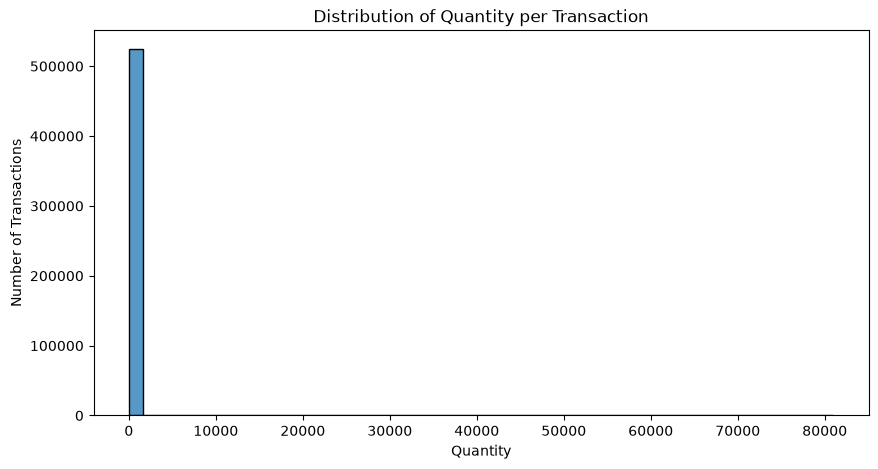

In [229]:
# Visualize the distribution of units sold per transaction row.

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_fe,
    x="Quantity",
    bins=50
)

plt.title("Distribution of Quantity per Transaction")
plt.xlabel("Quantity")
plt.ylabel("Number of Transactions")
plt.show()

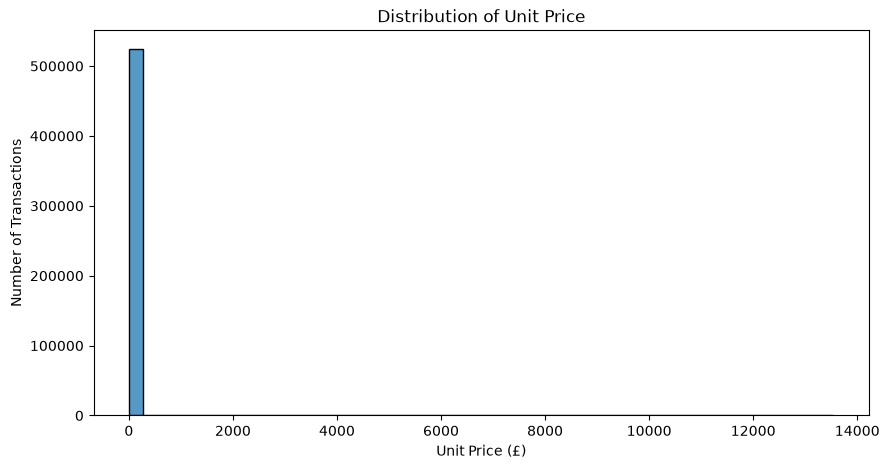

In [230]:
# Visualize the distribution of unit prices.

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_fe,
    x="UnitPrice",
    bins=50
)

plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price (£)")
plt.ylabel("Number of Transactions")
plt.show()

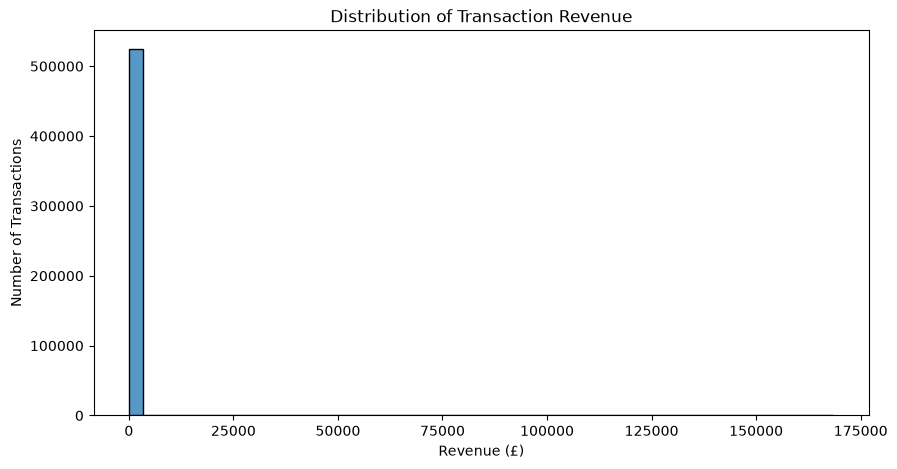

In [231]:
# Visualize transaction-level revenue.

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_fe,
    x="Revenue",
    bins=50
)

plt.title("Distribution of Transaction Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Number of Transactions")
plt.show()

### Top countries by transaction count & visualize

In [236]:
# Identify the countries contributing the highest number of transaction records.

country_transaction_counts = (
    df_fe["Country"]
    .value_counts()
    .head(15)
)

country_transaction_counts

Country
United Kingdom     479985
Germany              9025
France               8392
EIRE                 7879
Spain                2479
Netherlands          2359
Belgium              2031
Switzerland          1958
Portugal             1492
Australia            1181
Norway               1071
Italy                 758
Channel Islands       747
Finland               685
Cyprus                603
Name: count, dtype: int64

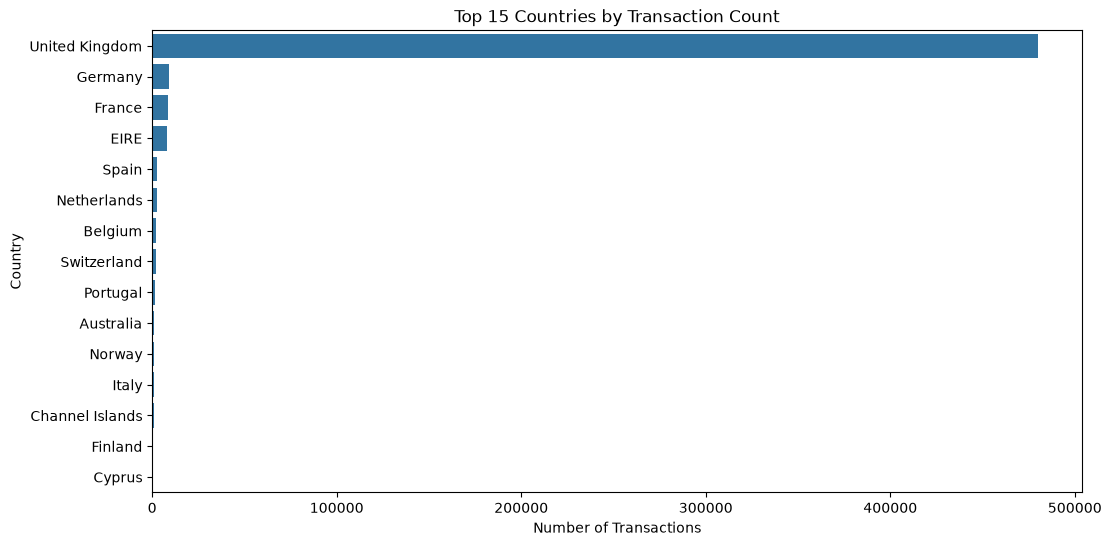

In [237]:
# Visualize the countries with the largest transaction volumes.

plt.figure(figsize=(12, 6))

sns.barplot(
    x=country_transaction_counts.values,
    y=country_transaction_counts.index
)

plt.title("Top 15 Countries by Transaction Count")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.show()

### Most frequently appearing products & visualize

In [238]:
# Identify the most frequently occurring product descriptions in transaction records.

top_products = (
    df_fe["Description"]
    .value_counts()
    .head(15)
)

top_products

Description
WHITE HANGING HEART T-LIGHT HOLDER    2311
JUMBO BAG RED RETROSPOT               2109
REGENCY CAKESTAND 3 TIER              2007
PARTY BUNTING                         1699
LUNCH BAG RED RETROSPOT               1581
ASSORTED COLOUR BIRD ORNAMENT         1476
SET OF 3 CAKE TINS PANTRY DESIGN      1392
PACK OF 72 RETROSPOT CAKE CASES       1352
LUNCH BAG  BLACK SKULL.               1301
NATURAL SLATE HEART CHALKBOARD        1255
JUMBO BAG PINK POLKADOT               1232
HEART OF WICKER SMALL                 1219
JUMBO STORAGE BAG SUKI                1194
PAPER CHAIN KIT 50'S CHRISTMAS        1184
JUMBO SHOPPER VINTAGE RED PAISLEY     1180
Name: count, dtype: int64

### Correlation matrix

In [239]:
# Examine linear relationships among the principal numerical variables.

correlation_columns = [
    "Quantity",
    "UnitPrice",
    "Revenue",
    "InvoiceTotalQuantity",
    "InvoiceTotalRevenue",
    "InvoiceUniqueProducts",
    "InvoiceAvgUnitPrice"
]

correlation_matrix = df_fe[correlation_columns].corr()

correlation_matrix

,Quantity,UnitPrice,Revenue,InvoiceTotalQuantity,InvoiceTotalRevenue,InvoiceUniqueProducts,InvoiceAvgUnitPrice
Quantity,1.000000,-0.003788,0.907402,0.225237,0.129493,-0.025943,-0.002237
UnitPrice,-0.003788,1.000000,0.137381,-0.000001,0.030548,0.016855,0.874851
Revenue,0.907402,0.137381,1.000000,0.210229,0.160134,-0.020358,0.121008
InvoiceTotalQuantity,0.225237,-0.000001,0.210229,1.000000,0.835170,0.445800,-0.000001
InvoiceTotalRevenue,0.129493,0.030548,0.160134,0.835170,1.000000,0.679248,0.034918
InvoiceUniqueProducts,-0.025943,0.016855,-0.020358,0.445800,0.679248,1.000000,0.019267
InvoiceAvgUnitPrice,-0.002237,0.874851,0.121008,-0.000001,0.034918,0.019267,1.000000


### Correlation heatmap

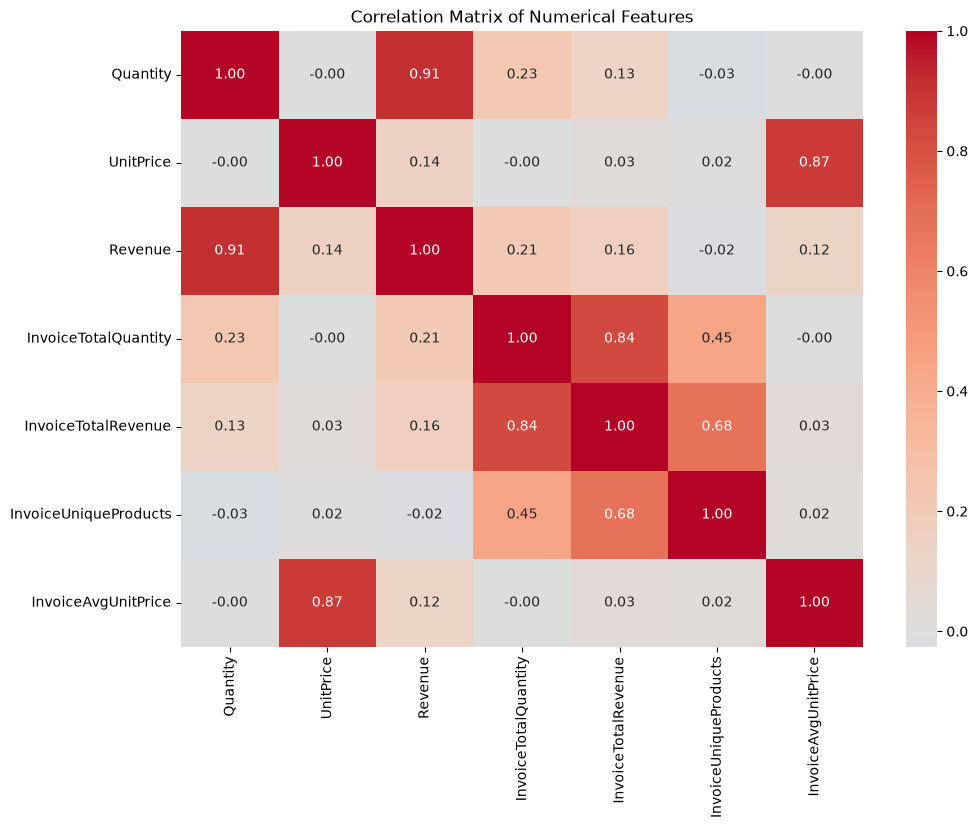

In [240]:
# Visualize the correlation structure among the numerical variables.

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

### Quantity vs Revenue

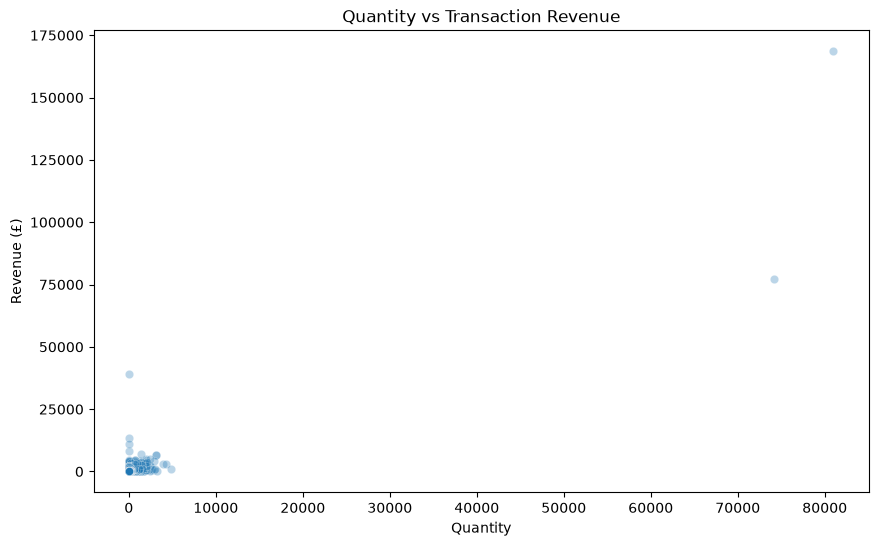

In [241]:
# Examine whether transaction quantity is associated with transaction revenue.

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_fe,
    x="Quantity",
    y="Revenue",
    alpha=0.3
)

plt.title("Quantity vs Transaction Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue (£)")
plt.show()

### Unit Price vs Revenue

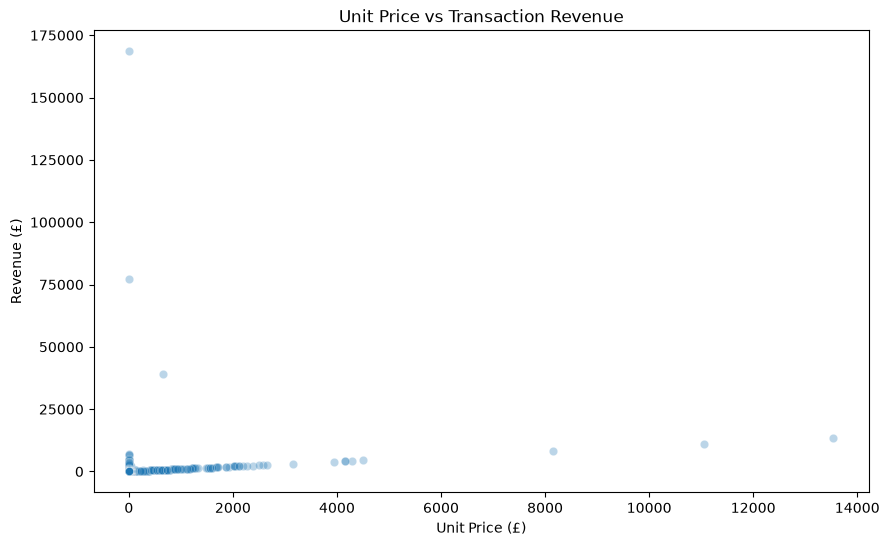

In [242]:
# Examine the relationship between unit price and transaction revenue.

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_fe,
    x="UnitPrice",
    y="Revenue",
    alpha=0.3
)

plt.title("Unit Price vs Transaction Revenue")
plt.xlabel("Unit Price (£)")
plt.ylabel("Revenue (£)")
plt.show()

### Basic EDA outlier counts

In [243]:
# Quantify observations beyond the IQR-based upper bound for key numerical variables.

def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    
    return (series > upper_bound).sum(), upper_bound

for column in ["Quantity", "UnitPrice", "Revenue"]:
    count, upper_bound = iqr_outlier_count(df_fe[column])
    
    print(f"{column}")
    print(f"Upper IQR bound: {upper_bound:.2f}")
    print(f"Outlier count: {count}")
    print()

Quantity
Upper IQR bound: 26.00
Outlier count: 27111

UnitPrice
Upper IQR bound: 8.45
Outlier count: 37827

Revenue
Upper IQR bound: 38.40
Outlier count: 42624



### Check negative quantities and revenue

In [244]:
# Check negative quantities
negative_quantity = df_fe[df_fe["Quantity"] < 0]
negative_quantity.shape

(0, 25)

In [245]:
negative_quantity[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "Revenue",
        "CustomerID",
        "Country"
    ]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID,Country


In [246]:
negative_revenue = df_fe[df_fe["Revenue"] < 0]
negative_revenue.shape

(0, 25)

### Investigate extremely large quantities, unit price, revenue

In [247]:
df_fe[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "Revenue",
        "CustomerID",
        "Country"
    ]
].sort_values(
    "Quantity",
    ascending=False
).head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID,Country
523404,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0,United Kingdom
59649,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0,United Kingdom
408238,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,1008.00,12901.0,United Kingdom
199399,554868,22197,SMALL POPCORN HOLDER,4300,0.72,3096.00,13135.0,United Kingdom
94208,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,3202.92,18087.0,United Kingdom
262196,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,191.16,14609.0,United Kingdom
50902,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
155191,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
420062,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,0.32,960.00,16308.0,United Kingdom
4784,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,0.18,518.40,16754.0,United Kingdom


In [248]:
df_fe[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "Revenue",
        "CustomerID",
        "Country"
    ]
].sort_values(
    "UnitPrice",
    ascending=False
).head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID,Country
14456,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,NaN,United Kingdom
290506,A563185,B,Adjust bad debt,1,11062.06,11062.06,NaN,United Kingdom
167609,551697,POST,POSTAGE,1,8142.75,8142.75,16029.0,United Kingdom
288286,562955,DOT,DOTCOM POSTAGE,1,4505.17,4505.17,NaN,United Kingdom
259507,560373,M,Manual,1,4287.63,4287.63,NaN,United Kingdom
408928,573077,M,Manual,1,4161.06,4161.06,12536.0,France
408952,573080,M,Manual,1,4161.06,4161.06,12536.0,France
393568,571751,M,Manual,1,3949.32,3949.32,12744.0,Singapore
363041,569382,M,Manual,1,3155.95,3155.95,15502.0,United Kingdom
337159,567353,M,Manual,1,2653.95,2653.95,NaN,Hong Kong


In [249]:
df_fe[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "Revenue",
        "CustomerID",
        "Country"
    ]
].sort_values(
    "Revenue",
    ascending=False
).head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID,Country
523404,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0,United Kingdom
59649,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0,United Kingdom
215474,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,15098.0,United Kingdom
14456,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,NaN,United Kingdom
290506,A563185,B,Adjust bad debt,1,11062.06,11062.06,NaN,United Kingdom
167609,551697,POST,POSTAGE,1,8142.75,8142.75,16029.0,United Kingdom
337516,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,17450.0,United Kingdom
50902,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
155191,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
408207,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,4992.00,14646.0,Netherlands


### Transaction distribution by day of wee

In [250]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_transaction_counts = (
    df_fe["DayName"]
    .value_counts()
    .reindex(day_order)
)

day_transaction_counts

DayName
Monday        92466.0
Tuesday       98726.0
Wednesday     91467.0
Thursday     100213.0
Friday        79667.0
Saturday          NaN
Sunday        62339.0
Name: count, dtype: float64

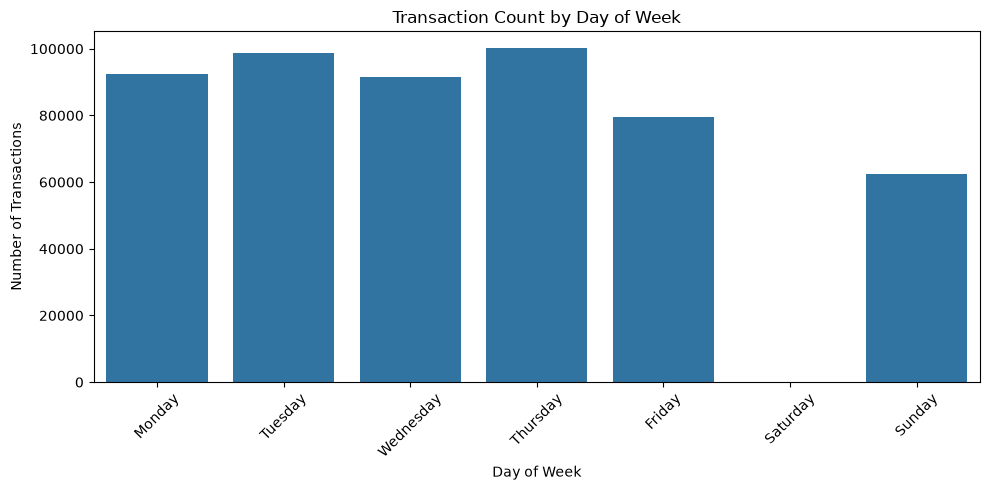

In [251]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=day_transaction_counts.index,
    y=day_transaction_counts.values
)

plt.title("Transaction Count by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Transaction distribution by month

In [252]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

month_transaction_counts = (
    df_fe["MonthName"]
    .value_counts()
    .reindex(month_order)
)

month_transaction_counts

MonthName
January      34060
February     26882
March        35497
April        28882
May          35917
June         35716
July         38395
August       34264
September    48900
October      58537
November     82004
December     65824
Name: count, dtype: int64

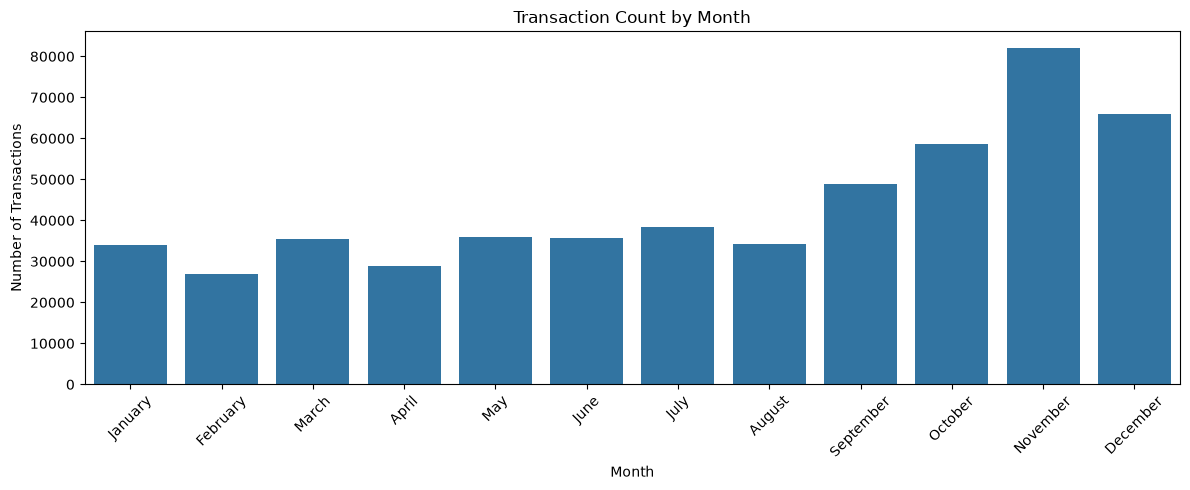

In [253]:
plt.figure(figsize=(12, 5))

sns.barplot(
    x=month_transaction_counts.index,
    y=month_transaction_counts.values
)

plt.title("Transaction Count by Month")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Transaction Count by Hour

In [254]:
hour_transaction_counts = (
    df_fe["Hour"]
    .value_counts()
    .sort_index()
)

hour_transaction_counts

Hour
6         1
7       379
8      8797
9     33684
10    47597
11    55420
12    75986
13    69993
14    65057
15    75665
16    52992
17    27426
18     7676
19     3427
20      778
Name: count, dtype: int64

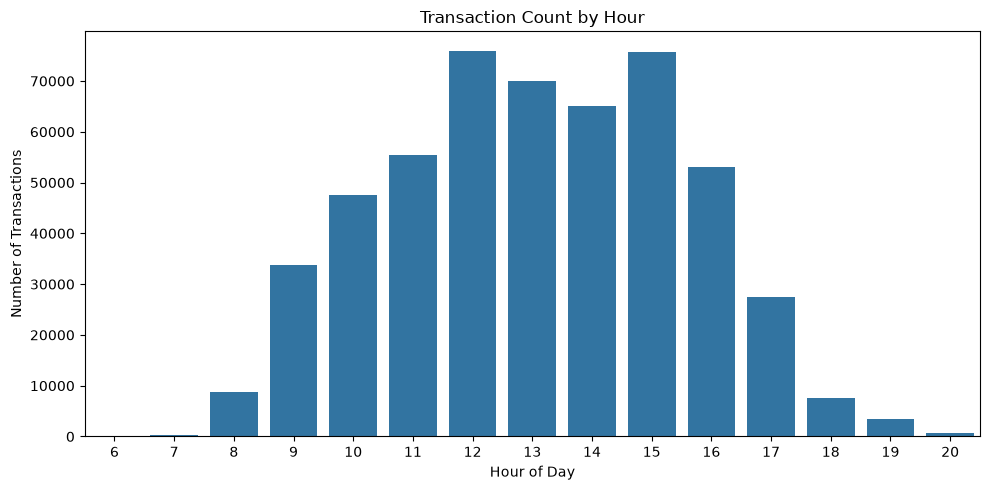

In [255]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=hour_transaction_counts.index,
    y=hour_transaction_counts.values
)

plt.title("Transaction Count by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

### Weekday vs Weekend Transactions

In [256]:
weekend_transaction_counts = (
    df_fe["IsWeekend"]
    .value_counts()
    .sort_index()
)

weekend_transaction_counts

IsWeekend
False    462539
True      62339
Name: count, dtype: int64

In [257]:
weekend_transaction_counts.index = [
    "Weekday" if value == False else "Weekend"
    for value in weekend_transaction_counts.index
]

weekend_transaction_counts

Weekday    462539
Weekend     62339
Name: count, dtype: int64

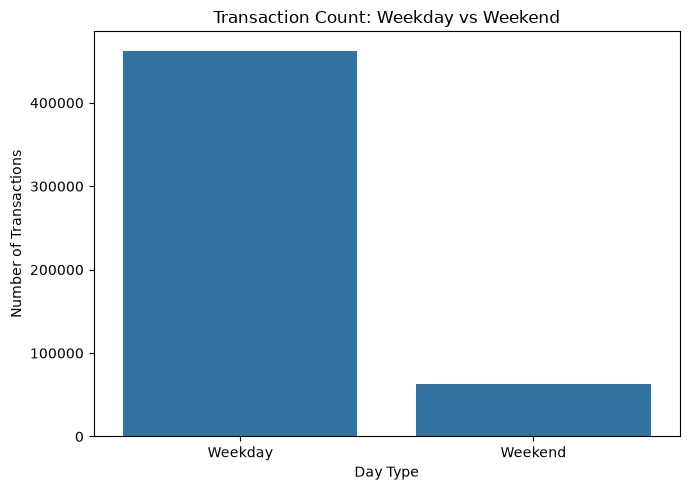

In [258]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=weekend_transaction_counts.index,
    y=weekend_transaction_counts.values
)

plt.title("Transaction Count: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

### Distribution of Invoice Sizes

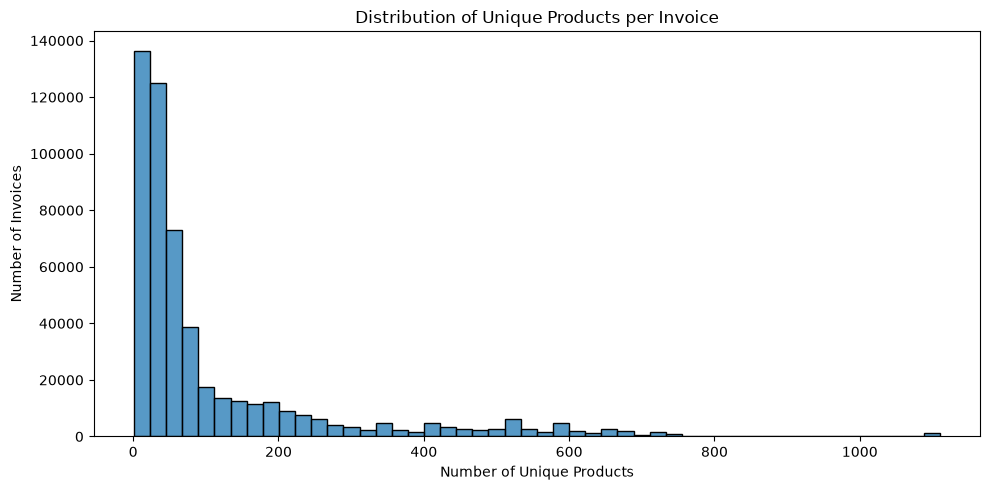

In [259]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_fe["InvoiceUniqueProducts"],
    bins=50
)

plt.title("Distribution of Unique Products per Invoice")
plt.xlabel("Number of Unique Products")
plt.ylabel("Number of Invoices")
plt.tight_layout()
plt.show()

In [260]:
invoice_level = (
    df_fe[
        ["InvoiceNo", "InvoiceUniqueProducts", "InvoiceTotalQuantity",
         "InvoiceTotalRevenue"]
    ]
    .drop_duplicates("InvoiceNo")
)

invoice_level.head()

,InvoiceNo,InvoiceUniqueProducts,InvoiceTotalQuantity,InvoiceTotalRevenue
0,536365,7,40,139.12
7,536366,2,12,22.20
9,536367,12,83,278.73
21,536368,4,15,70.05
25,536369,1,3,17.85


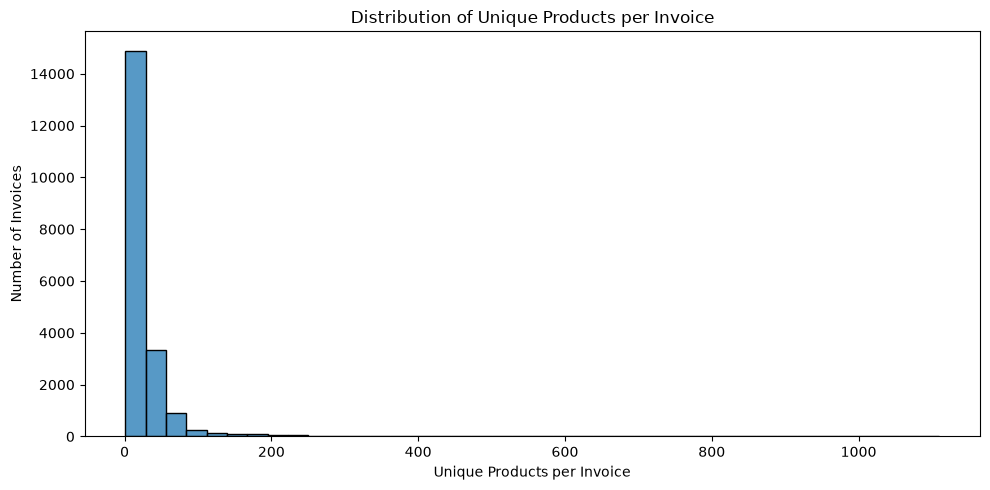

In [261]:
plt.figure(figsize=(10, 5))

sns.histplot(
    invoice_level["InvoiceUniqueProducts"],
    bins=40
)

plt.title("Distribution of Unique Products per Invoice")
plt.xlabel("Unique Products per Invoice")
plt.ylabel("Number of Invoices")
plt.tight_layout()
plt.show()

### Invoice-Level Descriptive Statistics

In [262]:
invoice_level[
    [
        "InvoiceTotalQuantity",
        "InvoiceTotalRevenue",
        "InvoiceUniqueProducts"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
InvoiceTotalQuantity,19960.0,279.179359,955.011810,1.00,69.000,150.0,296.0000,80995.0
InvoiceTotalRevenue,19960.0,533.171884,1780.412288,0.38,151.695,303.3,493.4625,168469.6
InvoiceUniqueProducts,19960.0,26.032164,46.982195,1.00,6.000,15.0,29.0000,1110.0


### Skewness analysis

In [263]:
skewness = (
    df_fe[
        [
            "Quantity",
            "UnitPrice",
            "Revenue",
            "InvoiceTotalQuantity",
            "InvoiceTotalRevenue",
            "InvoiceUniqueProducts",
            "InvoiceAvgUnitPrice"
        ]
    ]
    .skew()
    .sort_values(ascending=False)
)

skewness

Revenue                  504.232562
Quantity                 469.541785
InvoiceAvgUnitPrice      290.250350
UnitPrice                205.085168
InvoiceTotalQuantity       9.761388
InvoiceTotalRevenue        7.251651
InvoiceUniqueProducts      2.473866
dtype: float64

### Correlation Analysis

In [264]:
correlation_cols = [
    "Quantity",
    "UnitPrice",
    "Revenue",
    "InvoiceTotalQuantity",
    "InvoiceTotalRevenue",
    "InvoiceUniqueProducts",
    "InvoiceAvgUnitPrice"
]

correlation_matrix = df_fe[correlation_cols].corr()

correlation_matrix

,Quantity,UnitPrice,Revenue,InvoiceTotalQuantity,InvoiceTotalRevenue,InvoiceUniqueProducts,InvoiceAvgUnitPrice
Quantity,1.000000,-0.003788,0.907402,0.225237,0.129493,-0.025943,-0.002237
UnitPrice,-0.003788,1.000000,0.137381,-0.000001,0.030548,0.016855,0.874851
Revenue,0.907402,0.137381,1.000000,0.210229,0.160134,-0.020358,0.121008
InvoiceTotalQuantity,0.225237,-0.000001,0.210229,1.000000,0.835170,0.445800,-0.000001
InvoiceTotalRevenue,0.129493,0.030548,0.160134,0.835170,1.000000,0.679248,0.034918
InvoiceUniqueProducts,-0.025943,0.016855,-0.020358,0.445800,0.679248,1.000000,0.019267
InvoiceAvgUnitPrice,-0.002237,0.874851,0.121008,-0.000001,0.034918,0.019267,1.000000


In [265]:
correlation_matrix.round(2)

,Quantity,UnitPrice,Revenue,InvoiceTotalQuantity,InvoiceTotalRevenue,InvoiceUniqueProducts,InvoiceAvgUnitPrice
Quantity,1.00,-0.00,0.91,0.23,0.13,-0.03,-0.00
UnitPrice,-0.00,1.00,0.14,-0.00,0.03,0.02,0.87
Revenue,0.91,0.14,1.00,0.21,0.16,-0.02,0.12
InvoiceTotalQuantity,0.23,-0.00,0.21,1.00,0.84,0.45,-0.00
InvoiceTotalRevenue,0.13,0.03,0.16,0.84,1.00,0.68,0.03
InvoiceUniqueProducts,-0.03,0.02,-0.02,0.45,0.68,1.00,0.02
InvoiceAvgUnitPrice,-0.00,0.87,0.12,-0.00,0.03,0.02,1.00


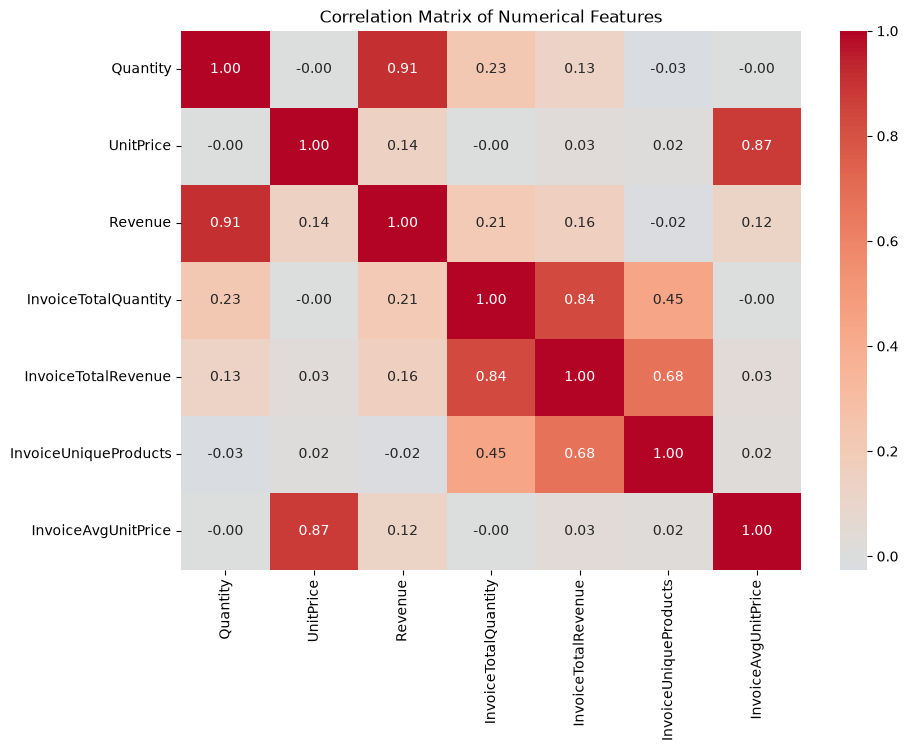

In [266]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

### Log-transformed Revenue, quantity, unit price

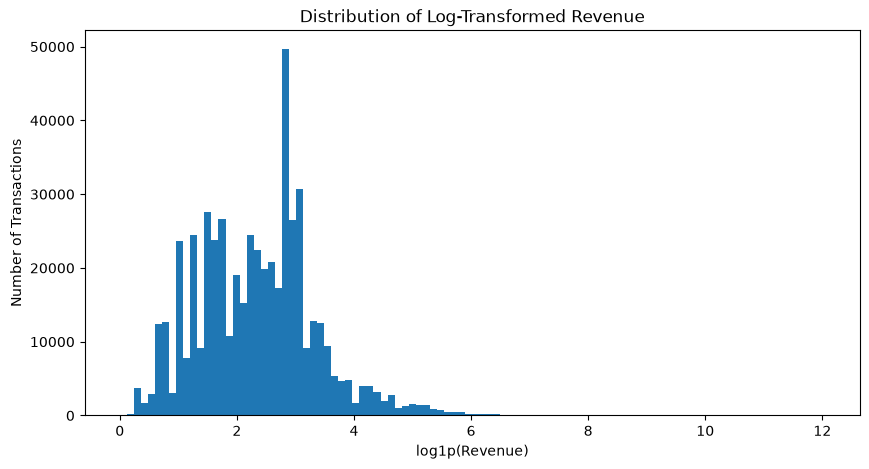

In [269]:
plt.figure(figsize=(10, 5))

plt.hist(
    np.log1p(df_fe["Revenue"]),
    bins=100
)

plt.title("Distribution of Log-Transformed Revenue")
plt.xlabel("log1p(Revenue)")
plt.ylabel("Number of Transactions")

plt.show()

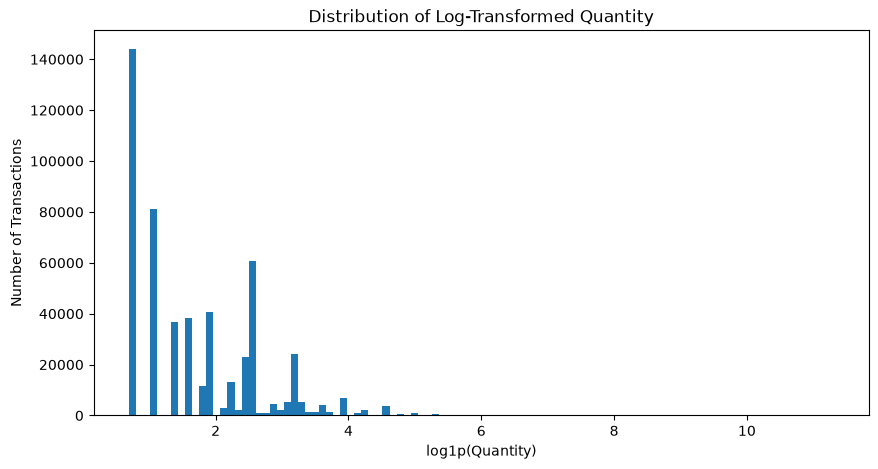

In [270]:
plt.figure(figsize=(10, 5))

plt.hist(
    np.log1p(df_fe["Quantity"]),
    bins=100
)

plt.title("Distribution of Log-Transformed Quantity")
plt.xlabel("log1p(Quantity)")
plt.ylabel("Number of Transactions")

plt.show()

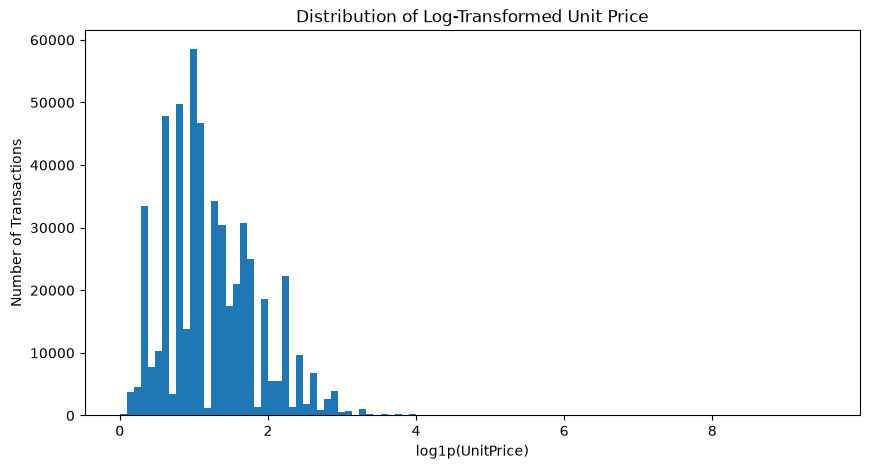

In [271]:
plt.figure(figsize=(10, 5))

plt.hist(
    np.log1p(df_fe["UnitPrice"]),
    bins=100
)

plt.title("Distribution of Log-Transformed Unit Price")
plt.xlabel("log1p(UnitPrice)")
plt.ylabel("Number of Transactions")

plt.show()

### Boxplots for revenue, quantity, unit price

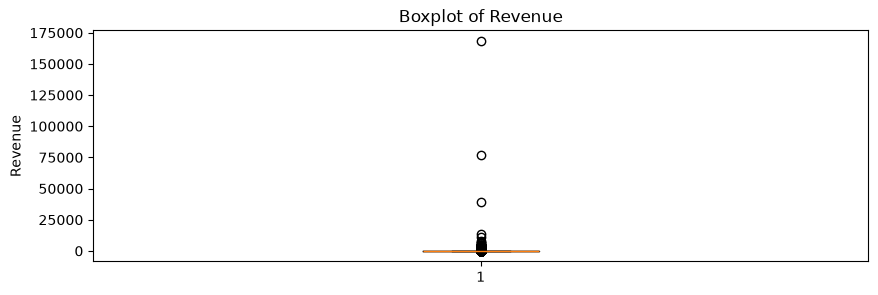

In [273]:
plt.figure(figsize=(10, 3))

plt.boxplot(df_fe["Revenue"])

plt.title("Boxplot of Revenue")
plt.ylabel("Revenue")

plt.show()

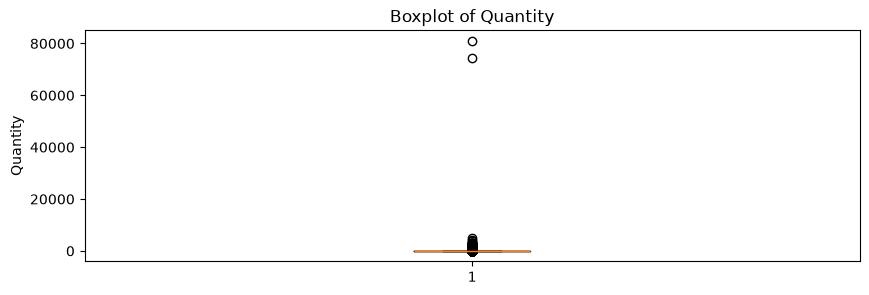

In [274]:
plt.figure(figsize=(10, 3))

plt.boxplot(df_fe["Quantity"])

plt.title("Boxplot of Quantity")
plt.ylabel("Quantity")

plt.show()

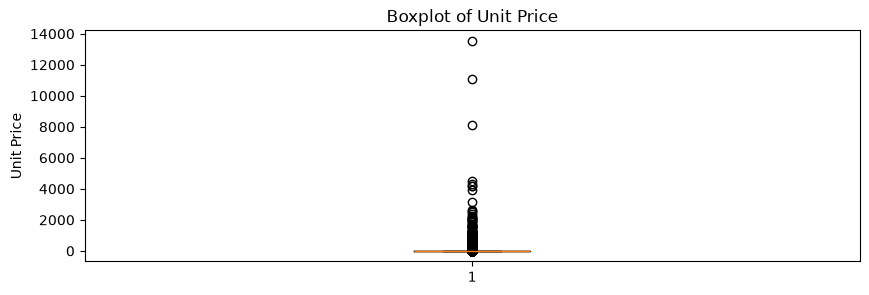

In [275]:
plt.figure(figsize=(10, 3))

plt.boxplot(df_fe["UnitPrice"])

plt.title("Boxplot of Unit Price")
plt.ylabel("Unit Price")

plt.show()

## 5. Exploratory Data Analysis (EDA) : Deductions

Exploratory Data Analysis was performed to understand the distribution, relationships, transaction patterns, and overall structure of the cleaned retail dataset. The analysis focuses on transaction activity, invoice-level behaviour, numerical feature distributions, skewness, outliers, and relationships among numerical variables.

The analysis was performed after the data cleaning and feature engineering stages, using the cleaned dataset `df_fe` and the engineered invoice-level dataset `invoice_level`.

---

## 5.1 Transaction Activity by Month

The number of transactions was analysed across months to identify seasonal patterns and changes in business activity throughout the year.

The monthly transaction counts were:

| Month | Transactions |
|---|---:|
| January | 34,060 |
| February | 26,882 |
| March | 35,497 |
| April | 28,882 |
| May | 35,917 |
| June | 35,716 |
| July | 33,395 |
| August | 34,264 |
| September | 48,900 |
| October | 58,537 |
| November | 82,004 |
| December | 65,824 |

### Deduction

Transaction activity varies considerably throughout the year. The first eight months show relatively moderate and fluctuating activity, while transaction volume increases substantially from September onward.

November records the highest transaction volume with **82,004 transactions**, followed by December with **65,824 transactions**. September and October also show a clear increase compared with the earlier months.

This indicates a strong increase in business activity during the later part of the year, particularly during **September–December**, suggesting a possible seasonal or holiday-related demand pattern.

February records the lowest transaction count with **26,882 transactions**.

---

## 5.2 Transaction Activity by Day of Week

Transaction counts were also examined across the days of the week.

| Day | Transactions |
|---|---:|
| Monday | 92,466 |
| Tuesday | 98,726 |
| Wednesday | 91,467 |
| Thursday | 100,213 |
| Friday | 79,667 |
| Saturday | No transactions |
| Sunday | 62,339 |

### Deduction

Transactions are concentrated heavily on weekdays.

**Thursday** has the highest transaction volume with **100,213 transactions**, followed by Tuesday with **98,726 transactions**. Friday has comparatively lower activity, while Sunday records the lowest non-zero transaction volume.

No transactions were recorded on Saturday in the dataset.

Overall, the dataset indicates that customer activity is substantially higher during the working week than during the weekend.

---

## 5.3 Weekday vs Weekend Transaction Activity

The transactions were grouped into two categories: **Weekday** and **Weekend**.

The analysis shows approximately:

- **Weekday transactions:** ~460,000
- **Weekend transactions:** ~62,000

### Deduction

The business is strongly weekday-oriented. The vast majority of transactions occur from Monday to Friday, while weekend activity is considerably lower.

This suggests that the underlying retail business primarily operates or receives customer orders during weekdays.

The difference is large enough that day type can be considered an important temporal characteristic of transaction behaviour.

---

## 5.4 Transaction Activity by Hour

Transaction counts were analysed by hour of the day to identify the periods with the highest purchasing activity.

The observed pattern shows that transaction activity begins at a very low level in the early morning, rises sharply from approximately **8–9 AM**, and remains high throughout the middle of the day.

The strongest activity occurs around:

- **12 PM**
- **13 PM**
- **14 PM**
- **15 PM**

The highest transaction levels are observed around **12 PM and 15 PM**.

After approximately **4 PM**, transaction activity declines substantially and continues falling toward the evening.

### Deduction

Customer activity is strongly concentrated during **business/working hours** rather than throughout the entire day.

The sharp increase between approximately 8 AM and 12 PM indicates that the majority of transactions occur during the daytime. Activity remains high through the afternoon before declining after 4 PM.

Therefore, the most active operational period is approximately **late morning to mid-afternoon**.

This pattern is consistent with the strong weekday orientation observed earlier.

---

## 5.5 Distribution of Unique Products per Invoice

The number of unique products purchased within each invoice was analysed at the invoice level.

The invoice-level dataset contains **19,960 unique invoices**.

The descriptive statistics for `InvoiceUniqueProducts` are:

| Statistic | Value |
|---|---:|
| Count | 19,960 |
| Mean | 26.03 |
| Standard Deviation | 46.98 |
| Minimum | 1 |
| 25th Percentile | 6 |
| Median | 15 |
| 75th Percentile | 29 |
| Maximum | 1,111 |

### Deduction

The distribution of unique products per invoice is strongly right-skewed.

The median invoice contains **15 unique products**, while the mean is higher at approximately **26 products**. This difference indicates that a relatively small number of invoices contain exceptionally large numbers of different products and pull the mean upward.

Most invoices therefore contain a relatively modest number of unique products, while a small number of invoices contain hundreds of different products.

The maximum value of **1,111 unique products in a single invoice** is an extreme observation and contributes substantially to the long right tail.

---

## 5.6 Invoice-Level Descriptive Statistics

The invoice-level dataset was examined using descriptive statistics for the main engineered measures.

| Feature | Mean | Median | Std | Min | Max |
|---|---:|---:|---:|---:|---:|
| InvoiceTotalQuantity | 279.18 | 150.00 | 955.01 | 1 | 80,995 |
| InvoiceTotalRevenue | 533.17 | 303.30 | 1,780.41 | 0.38 | 168,469.60 |
| InvoiceUniqueProducts | 26.03 | 15.00 | 46.98 | 1 | 1,111 |

### Deduction

All three invoice-level measures show substantial variation between invoices.

For `InvoiceTotalQuantity`, the mean of approximately **279 units** is considerably higher than the median of **150 units**, indicating that a relatively small number of invoices contain exceptionally large quantities.

Similarly, `InvoiceTotalRevenue` has a mean of approximately **533.17**, compared with a median of **303.30**. This again indicates that a small number of high-value invoices substantially increase the average.

`InvoiceUniqueProducts` follows the same pattern, with a mean of **26.03** compared with a median of **15**.

Overall, invoice-level purchasing behaviour is highly heterogeneous: most invoices are relatively moderate in size, while a small number represent extremely large transactions.

---

## 5.7 Skewness Analysis

Skewness was calculated for the major transaction-level and invoice-level numerical features.

| Feature | Skewness |
|---|---:|
| Revenue | 504.23 |
| Quantity | 469.54 |
| InvoiceAvgUnitPrice | 290.25 |
| UnitPrice | 205.09 |
| InvoiceTotalQuantity | 9.76 |
| InvoiceTotalRevenue | 7.25 |
| InvoiceUniqueProducts | 2.47 |

### Deduction

The skewness results reveal that the numerical variables are **strongly right-skewed**, particularly the transaction-level variables.

`Revenue` has a skewness of approximately **504**, while `Quantity` has a skewness of approximately **470**. These are extremely high values and indicate the presence of a very long right tail.

`UnitPrice` is also highly right-skewed, with skewness of approximately **205**.

The invoice-level measures are less extreme but remain positively skewed. `InvoiceTotalQuantity` has skewness of approximately **9.76**, while `InvoiceTotalRevenue` has skewness of approximately **7.25`.

`InvoiceUniqueProducts` has the lowest skewness among the examined variables at approximately **2.47**, but it is still positively skewed.

### Overall interpretation

The mean should therefore be interpreted carefully for these variables because extreme observations can substantially influence it. Median and percentile-based statistics provide a more representative description of the typical transaction or invoice.

---

## 5.8 Distribution of Revenue

The raw distribution of transaction-level `Revenue` was visualised using a histogram.

The histogram shows a very large concentration of observations near the lower end of the revenue scale, while a small number of transactions extend to very high revenue values.

The distribution has a very long right tail, reaching values of approximately **168,470**.

### Deduction

Most transactions generate relatively small amounts of revenue, while a very small number of transactions generate exceptionally high revenue.

This confirms the extremely high skewness value of approximately **504** observed earlier.

The extreme range makes the raw histogram difficult to interpret because the very large observations compress the majority of transactions into a narrow region near zero.

---

## 5.9 Distribution of Quantity

The raw distribution of `Quantity` was also examined.

Similar to revenue, the majority of observations are concentrated at relatively low quantities, while a small number of transactions contain extremely large quantities.

The maximum transaction quantity reaches approximately **80,995 units**.

### Deduction

Transaction quantities are highly concentrated toward the lower end of the distribution, with a small number of extremely large orders creating a substantial right tail.

This agrees with the skewness value of approximately **469.54**.

The extreme values dominate the scale of the raw histogram, making it difficult to visually examine the distribution of ordinary transactions.

---

## 5.10 Distribution of Unit Price

The raw distribution of `UnitPrice` was examined using a histogram.

Most observations are concentrated at relatively low unit prices, while a small number of observations have exceptionally high prices.

The maximum observed unit price is approximately **13,541.33**.

### Deduction

The distribution of unit prices is heavily right-skewed, consistent with the skewness value of approximately **205.09**.

Most products are sold at comparatively low unit prices, while a small number of transactions contain unusually high unit-price values.

These extreme observations cause the raw histogram to compress the majority of normal observations toward the lower end of the scale.

---

## 5.11 Boxplot Analysis and Outliers

Boxplots were created for `Revenue`, `Quantity`, and `UnitPrice` to visually inspect extreme observations.

### Revenue

The revenue boxplot shows a large concentration of observations close to the lower range, accompanied by numerous high-value outliers.

A few observations are extremely distant from the main distribution, with the highest revenue reaching approximately **168,469.60**.

### Quantity

The quantity boxplot also reveals numerous upper-end outliers.

Most observations lie close to the lower range, while a small number of transactions have exceptionally large quantities. The most extreme observations reach approximately **80,995 units**.

### Unit Price

The unit-price boxplot shows a large number of upper-end outliers and several extremely high values.

The maximum unit price is approximately **13,541.33**.

### Deduction

The boxplots confirm that the extreme observations identified through skewness analysis are genuine characteristics of the observed data distribution rather than merely artifacts of the histogram scale.

However, an important distinction should be made:

> **An outlier is not automatically an invalid observation.**

These extreme transactions may represent legitimate bulk purchases, expensive products, special orders, or other genuine business activity.

Therefore, these observations should not automatically be removed simply because they fall outside the typical range.

---

## 5.12 Log-Transformed Revenue

Because the raw revenue distribution was extremely right-skewed, `log1p(Revenue)` was used for visualization.

The logarithmic transformation compresses very large revenue values while preserving the ordering of observations.

### Deduction

The log-transformed distribution provides a substantially clearer view of the underlying concentration of transaction revenue.

Instead of the majority of observations being compressed near zero, the transformed distribution spreads the lower and middle ranges across a more interpretable scale.

The distribution remains right-skewed, but the extreme tail is considerably less dominant.

The transformation was used **only for exploratory visualization** and does not replace the original revenue values in the cleaned dataset.

---

## 5.13 Log-Transformed Quantity

`log1p(Quantity)` was used to visualise the highly skewed quantity distribution.

### Deduction

The logarithmic transformation substantially reduces the influence of extremely large quantity values and makes the distribution of ordinary transactions easier to observe.

The transformed distribution still contains a right tail, indicating that high-volume transactions remain present, but the extreme quantities no longer dominate the visualisation to the same extent as in the raw histogram.

Again, this transformation was used for **EDA and visual interpretation**, not as a replacement for the original `Quantity` column.

---

## 5.14 Log-Transformed Unit Price

The `UnitPrice` distribution was also examined after applying `log1p()`.

### Deduction

The log transformation compresses the extreme high-price observations and provides a much clearer view of the central concentration of unit prices.

Although the distribution remains somewhat right-skewed, the extreme values have substantially less visual dominance.

This confirms that the raw unit-price distribution is heavily influenced by a relatively small number of high-value observations.

---

## 5.15 Correlation Analysis

A correlation matrix was created to understand linear relationships among the major numerical transaction-level and invoice-level variables.

The most notable correlations were:

| Variable Pair | Correlation |
|---|---:|
| Quantity ↔ Revenue | **0.91** |
| InvoiceTotalQuantity ↔ InvoiceTotalRevenue | **0.84** |
| UnitPrice ↔ InvoiceAvgUnitPrice | **0.87** |
| InvoiceTotalRevenue ↔ InvoiceUniqueProducts | **0.68** |
| InvoiceTotalQuantity ↔ InvoiceUniqueProducts | **0.45** |
| Quantity ↔ InvoiceTotalQuantity | 0.23 |
| Revenue ↔ InvoiceTotalRevenue | 0.16 |
| Revenue ↔ UnitPrice | 0.14 |
| Quantity ↔ InvoiceUniqueProducts | -0.03 |

### Deduction

The strongest relationship among transaction-level variables is between **Quantity and Revenue (0.91)**.

This is expected because transaction revenue is directly calculated from quantity and unit price:

`Revenue = Quantity × UnitPrice`

Therefore, higher quantities generally lead to higher transaction revenue, although the relationship is not perfectly 1.0 because unit prices vary across products.

At the invoice level, `InvoiceTotalQuantity` and `InvoiceTotalRevenue` also show a strong positive correlation of **0.84**, indicating that invoices containing larger quantities generally generate greater revenue.

`InvoiceTotalRevenue` and `InvoiceUniqueProducts` have a moderate-to-strong positive correlation of **0.68**. This suggests that invoices containing a larger variety of products tend to generate higher revenue.

Similarly, `InvoiceTotalQuantity` and `InvoiceUniqueProducts` have a moderate positive correlation of **0.45**, suggesting that invoices with more unique products generally contain higher total quantities.

`UnitPrice` and `InvoiceAvgUnitPrice` show a strong positive correlation of **0.87**. This is reasonable because the average unit price at the invoice level is influenced by the unit prices of the products included in that invoice.

Most importantly, correlation should be interpreted as **association rather than causation**. A high correlation does not by itself establish that one variable causes another.

---

## 5.16 Overall EDA Findings

The EDA reveals several important characteristics of the retail dataset:

1. **Transaction activity is highly seasonal.**  
   Activity increases considerably during the latter part of the year, with November recording the highest transaction volume.

2. **Transactions are strongly concentrated on weekdays.**  
   Weekday activity is substantially higher than weekend activity, while no Saturday transactions are present in the dataset.

3. **Transaction activity is concentrated during daytime hours.**  
   The strongest activity occurs from late morning through the afternoon, particularly around 12 PM–3 PM.

4. **Customer invoices vary substantially in size.**  
   Most invoices contain a moderate number of products and quantities, while a small number contain exceptionally large orders.

5. **Revenue, quantity, and unit price are extremely right-skewed.**  
   A small number of extreme observations have a disproportionate effect on the mean and visual scale.

6. **The boxplots confirm the presence of numerous high-end outliers.**  
   These observations should not automatically be treated as errors because they may represent legitimate business transactions.

7. **Log transformations improve visual interpretability.**  
   Applying `log1p()` compresses extreme values and makes the underlying distribution easier to inspect without modifying the original dataset.

8. **Quantity and revenue have a very strong positive relationship.**  
   The correlation between `Quantity` and `Revenue` is approximately **0.91**.

9. **Larger invoices tend to generate greater revenue.**  
   `InvoiceTotalQuantity` and `InvoiceTotalRevenue` have a correlation of approximately **0.84**.

10. **Product variety is associated with invoice value.**  
    `InvoiceUniqueProducts` has a correlation of approximately **0.68** with `InvoiceTotalRevenue`, indicating that invoices containing more distinct products tend to be associated with higher revenue.

11. **The dataset contains considerable heterogeneity.**  
    Typical transactions and invoices are substantially smaller than the extreme observations, making median, percentile, and distribution-based analysis particularly important.

Overall, the EDA establishes that the retail dataset exhibits **strong temporal patterns, highly skewed numerical distributions, substantial transaction-level variability, and meaningful relationships between purchasing volume, product variety, and revenue**.

These findings provide the foundation for the next stage of analysis: **Customer Behaviour Analysis**, where the focus will shift from general dataset patterns to individual customer purchasing behaviour, frequency, spending, and contribution to the business.